In [1]:
import os
import numpy as np
import random
print("OK")

OK


In [2]:
from PIL import Image
print("PIL OK")

PIL OK


In [3]:
import matplotlib.pyplot as plt
print("matplotlib OK")

matplotlib OK


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
print("sklearn OK")

sklearn OK


In [5]:
import seaborn as sns
print("seaborn OK")

seaborn OK


In [6]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
print("TensorFlow Keras OK")

TensorFlow Keras OK


In [11]:
# Путь к папке с изображениями
images_path = r'C:\Users\Алексей\Desktop\Абсолютный слух\Data\images_original'
genres = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

# Новый целевой размер (больше деталей)
TARGET_SIZE = (400, 224)

X = []
y = []

def crop_white_borders_pil(img, threshold=250):
    arr = np.array(img)
    if len(arr.shape) == 3:
        gray = arr.mean(axis=2)
    else:
        gray = arr
    mask = gray < threshold
    coords = np.argwhere(mask)
    if coords.size == 0:
        return img
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0) + 1
    return img.crop((x_min, y_min, x_max, y_max))

for genre in genres:
    genre_path = os.path.join(images_path, genre)
    for filename in os.listdir(genre_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(genre_path, filename)
            try:
                img = Image.open(img_path).convert('L')
                img_cropped = crop_white_borders_pil(img, threshold=250)
                img_resized = img_cropped.resize(TARGET_SIZE, Image.Resampling.LANCZOS)
                img_array = np.array(img_resized).astype('float32') / 255.0
                X.append(img_array)
                y.append(genre)
            except Exception as e:
                print(f"Ошибка при обработке {img_path}: {e}")

X = np.array(X)
y = np.array(y)

print(f"Загружено {X.shape[0]} изображений, форма: {X.shape[1:]}")
print("Распределение по жанрам:")
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f"{u}: {c}")

Загружено 999 изображений, форма: (224, 400)
Распределение по жанрам:
blues: 100
classical: 100
country: 100
disco: 100
hiphop: 100
jazz: 99
metal: 100
pop: 100
reggae: 100
rock: 100


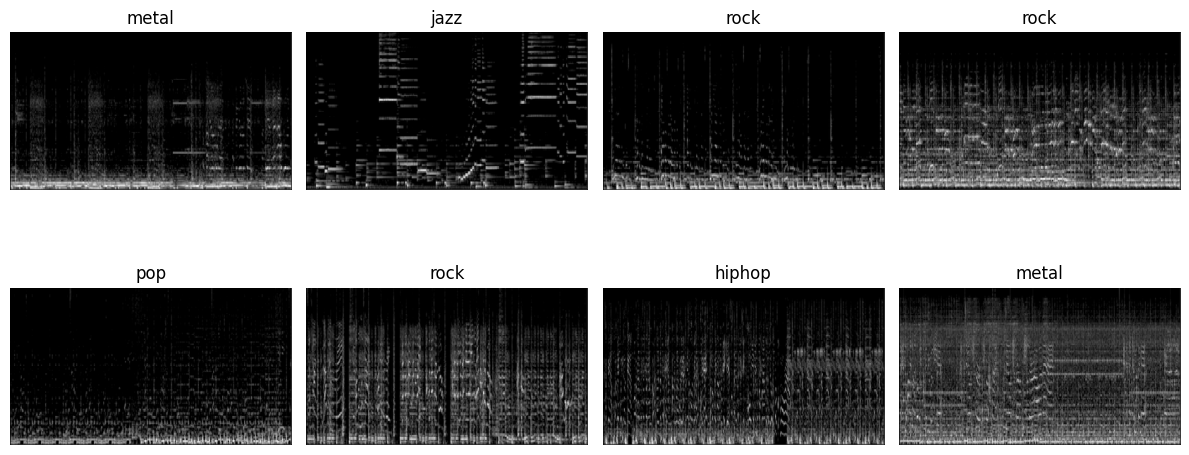

In [12]:
plt.figure(figsize=(12, 6))
for i in range(8):
    idx = random.randint(0, len(X)-1)
    plt.subplot(2, 4, i+1)
    plt.imshow(X[idx], cmap='gray')
    plt.title(y[idx])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [13]:
print(f"Форма X: {X.shape}")
print(f"Минимальное значение: {X.min()}, максимальное: {X.max()}")

Форма X: (999, 224, 400)
Минимальное значение: 0.0, максимальное: 1.0


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded, num_classes=10)

X_train, X_temp, y_train, y_temp = train_test_split(X, y_cat, test_size=0.3, random_state=42, stratify=y_encoded)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=np.argmax(y_temp, axis=1))

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Добавляем канал
X_train = np.expand_dims(X_train, -1)
X_val = np.expand_dims(X_val, -1)
X_test = np.expand_dims(X_test, -1)

Train: (699, 224, 400), Val: (150, 224, 400), Test: (150, 224, 400)


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Input(shape=(400, 224, 1)),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 400, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 200, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 200, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 100, 56, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 100, 56, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 50, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 50, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 25, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 89600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,937,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,328,266 (88.99 MB)

 Trainable params: 23,328,266 (88.99 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,  # уменьшил из-за большего размера
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.1187 - loss: 2.3253 - val_accuracy: 0.1533 - val_loss: 2.2598 - learning_rate: 0.0010
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.1831 - loss: 2.1815 - val_accuracy: 0.2067 - val_loss: 2.0099 - learning_rate: 0.0010
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.2303 - loss: 2.0671 - val_accuracy: 0.3533 - val_loss: 1.8954 - learning_rate: 0.0010
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.2904 - loss: 1.9329 - val_accuracy: 0.3600 - val_loss: 1.7670 - learning_rate: 0.0010
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.3705 - loss: 1.7611 - val_accuracy: 0.4000 - val_loss: 1.6286 - learning_rate: 0.0010
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.4306 - loss: 1.6133 - val_accuracy: 0.4467 - val_loss: 1.4722 - learning_rate: 0.0010
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.4607 - loss: 1.5072 - val_accuracy

Test accuracy: 0.5133
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 806ms/step

Classification Report:
              precision    recall  f1-score   support

       blues       0.60      0.40      0.48        15
   classical       0.73      0.73      0.73        15
     country       0.42      0.67      0.51        15
       disco       0.31      0.27      0.29        15
      hiphop       0.44      0.53      0.48        15
        jazz       0.56      0.67      0.61        15
       metal       0.83      0.67      0.74        15
         pop       0.50      0.60      0.55        15
      reggae       0.47      0.53      0.50        15
        rock       0.20      0.07      0.10        15

    accuracy                           0.51       150
   macro avg       0.51      0.51      0.50       150
weighted avg       0.51      0.51      0.50       150



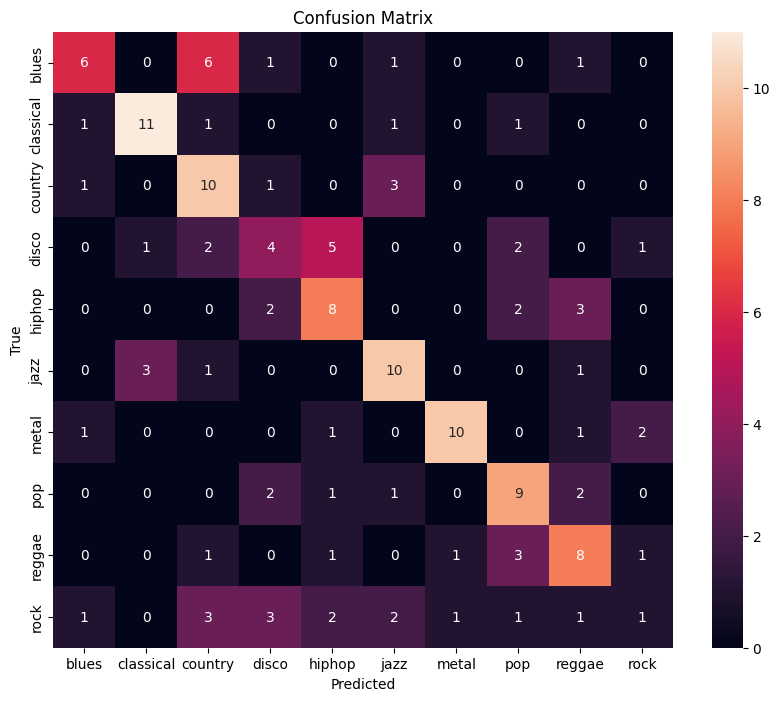

In [17]:
# Оценка на тесте
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

# Предсказания для отчёта
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_))

# Матрица ошибок
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [18]:
model.save('cnn_spectrogram_model.h5')
import joblib
joblib.dump(le, 'label_encoder_cnn.pkl')
print("Модель сохранена как 'cnn_spectrogram_model.h5'")
print("Encoder сохранён как 'label_encoder_cnn.pkl'")

Модель сохранена как 'cnn_spectrogram_model.h5'
Encoder сохранён как 'label_encoder_cnn.pkl'


In [20]:
import tensorflow as tf
import joblib
import numpy as np
import librosa
import matplotlib.pyplot as plt
from PIL import Image

# Загрузка модели и encoder
model = tf.keras.models.load_model('cnn_spectrogram_model.h5')
le = joblib.load('label_encoder_cnn.pkl')
print("Модель и encoder загружены")

Модель и encoder загружены


In [21]:
def audio_to_spectrogram(audio_path, target_size=(224, 400), sr=22050, duration=30, n_mels=224, hop_length=512):
    # Загрузка аудио
    y, _ = librosa.load(audio_path, sr=sr, mono=True, duration=duration)
    
    # Построение мел-спектрограммы
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, hop_length=hop_length)
    log_mel = librosa.power_to_db(mel_spec, ref=np.max)
    
    # Приведение к размеру target_size (высота = n_mels, ширина = количество кадров)
    # Сначала обрежем/дополним по времени до нужной ширины
    target_width = target_size[1]  # 400
    current_width = log_mel.shape[1]
    if current_width < target_width:
        pad_width = target_width - current_width
        log_mel = np.pad(log_mel, ((0,0), (0, pad_width)), mode='constant')
    else:
        log_mel = log_mel[:, :target_width]
    
    # Нормализация в [0,1] (как при обучении)
    log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min())
    
    # Приведение к размеру target_size (высота = target_size[0], ширина = target_size[1])
    # У нас высота уже n_mels, но может не совпадать с target_size[0]. Придётся изменить размер.
    # В датасете исходные спектрограммы имели другой размер, затем их ресайзили до 224×400.
    # Мы сделаем то же самое: используем PIL для ресайза.
    img = Image.fromarray((log_mel * 255).astype(np.uint8))
    img_resized = img.resize((target_size[1], target_size[0]), Image.Resampling.LANCZOS)
    img_array = np.array(img_resized).astype(np.float32) / 255.0
    # Добавляем канал
    img_array = np.expand_dims(img_array, axis=-1)
    return img_array

Топ-4 жанра:
metal: 98.2%
rock: 1.7%
reggae: 0.0%
disco: 0.0%


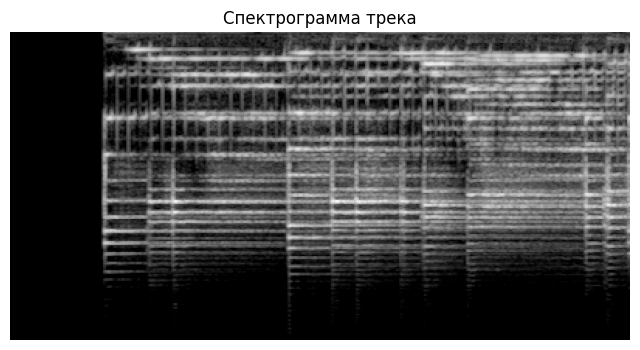

In [22]:
song_path = r'C:\Users\Алексей\Desktop\Абсолютный слух\песни\Bi-2_-_Polkovniku_nikto_ne_pishet_47829792.mp3'
try:
    spec = audio_to_spectrogram(song_path)
    # Предсказание
    pred_probs = model.predict(np.expand_dims(spec, axis=0), verbose=0)[0]
    top4_idx = np.argsort(pred_probs)[-4:][::-1]
    top4_genres = le.inverse_transform(top4_idx)
    top4_probs = pred_probs[top4_idx]
    
    print("Топ-4 жанра:")
    for g, p in zip(top4_genres, top4_probs):
        print(f"{g}: {p*100:.1f}%")
    
    # Визуализация спектрограммы
    plt.figure(figsize=(8,4))
    plt.imshow(spec.squeeze(), aspect='auto', cmap='gray')
    plt.title('Спектрограмма трека')
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"Ошибка: {e}")